In [2]:
import pandas as pd
df = pd.read_csv('train.csv')

In [3]:
print(df.head(5))

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
print(df['Sales'].describe())

count     4822.000000
mean       229.168572
std        637.194491
min          0.444000
25%         16.768000
50%         52.596000
75%        212.033500
max      22638.480000
Name: Sales, dtype: float64


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%B')
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

SALES TREND OVERTIME

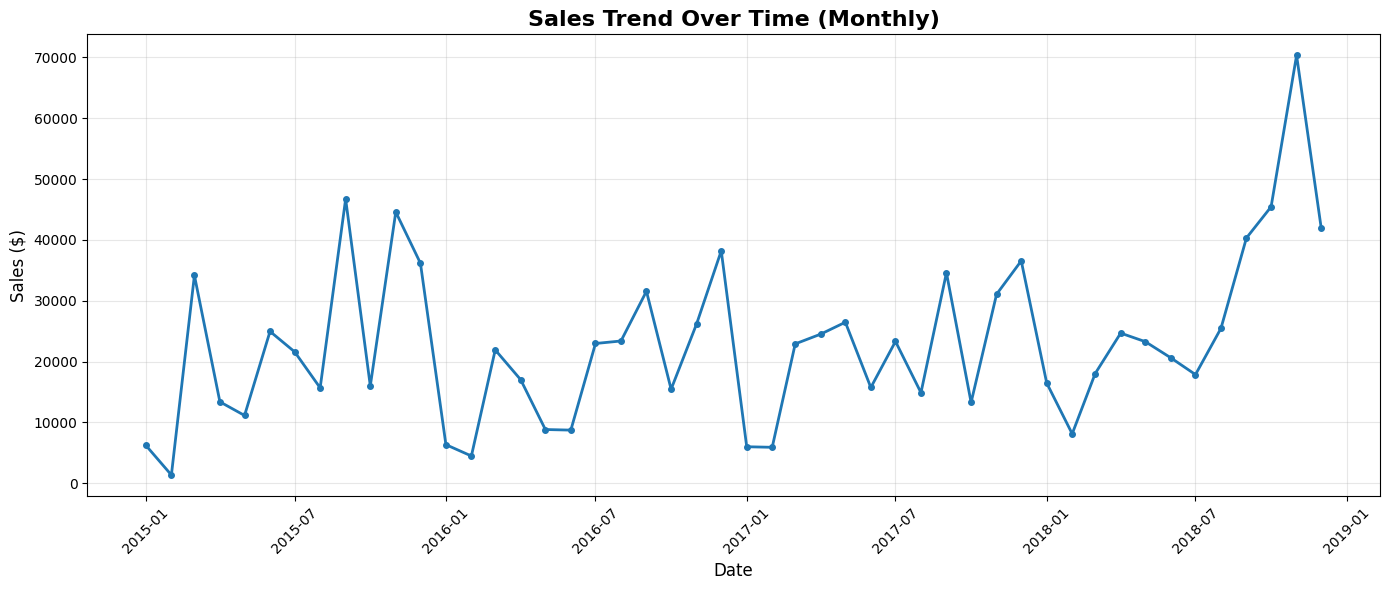


Total Sales per Tahun:
Year
2015    272027.1374
2016    225145.1450
2017    255283.0685
2018    352595.5018
Name: Sales, dtype: float64

Year-over-Year Growth (%):
Year
2016   -17.234307
2017    13.385998
2018    38.119423
Name: Sales, dtype: float64


In [6]:
import matplotlib.pyplot as plt

# Agregasi sales per bulan
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', linewidth=2, markersize=4)
plt.title('Sales Trend Over Time (Monthly)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Year-over-Year Growth
yearly_sales = df.groupby('Year')['Sales'].sum()
print("\nTotal Sales per Tahun:")
print(yearly_sales)

if len(yearly_sales) > 1:
    yoy_growth = yearly_sales.pct_change() * 100
    print("\nYear-over-Year Growth (%):")
    print(yoy_growth.dropna())

MONTHLY SEASONALITY PATTERN

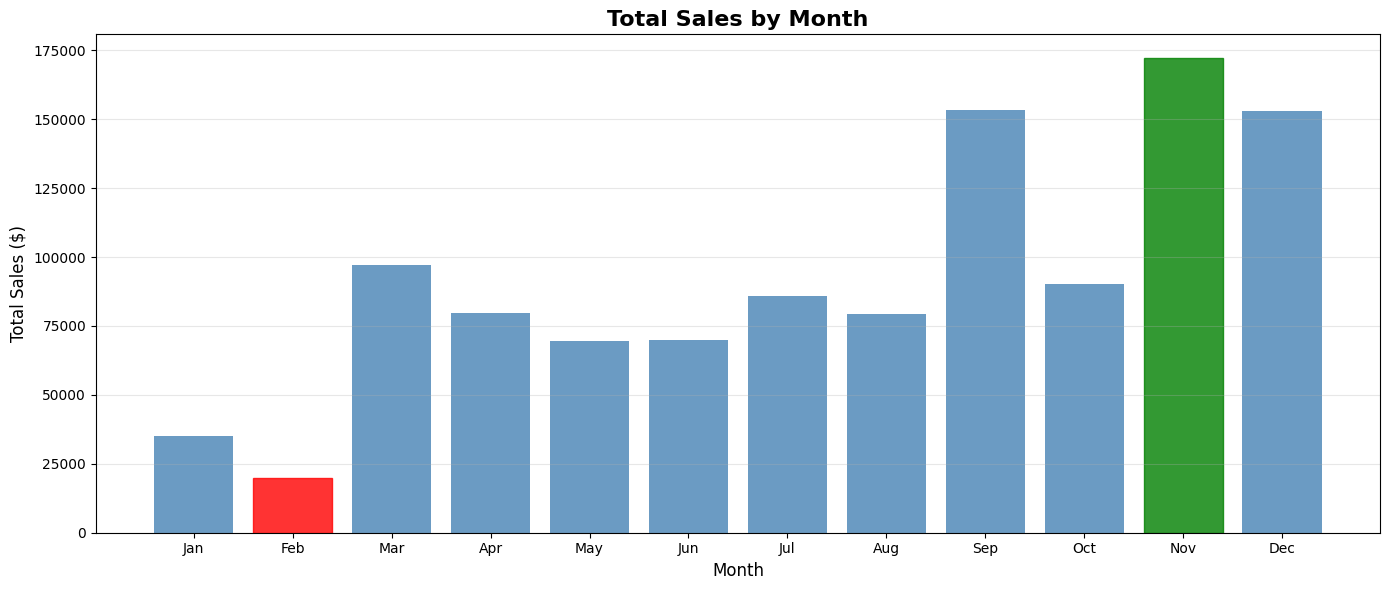


Bulan dengan sales TERTINGGI: Nov
Bulan dengan sales TERENDAH: Feb


In [7]:
monthly_avg = df.groupby('Month')['Sales'].agg(['sum', 'mean', 'count']).reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(14, 6))
bars = plt.bar(monthly_avg['Month'], monthly_avg['sum'], color='steelblue', alpha=0.8)
plt.title('Total Sales by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(range(1, 13), month_names)
plt.grid(axis='y', alpha=0.3)

# Highlight bulan tertinggi dan terendah
max_month = monthly_avg.loc[monthly_avg['sum'].idxmax(), 'Month']
min_month = monthly_avg.loc[monthly_avg['sum'].idxmin(), 'Month']
bars[max_month-1].set_color('green')
bars[min_month-1].set_color('red')

plt.tight_layout()
plt.show()

print(f"\nBulan dengan sales TERTINGGI: {month_names[max_month-1]}")
print(f"Bulan dengan sales TERENDAH: {month_names[min_month-1]}")

DAY OF WEEK PATTERN

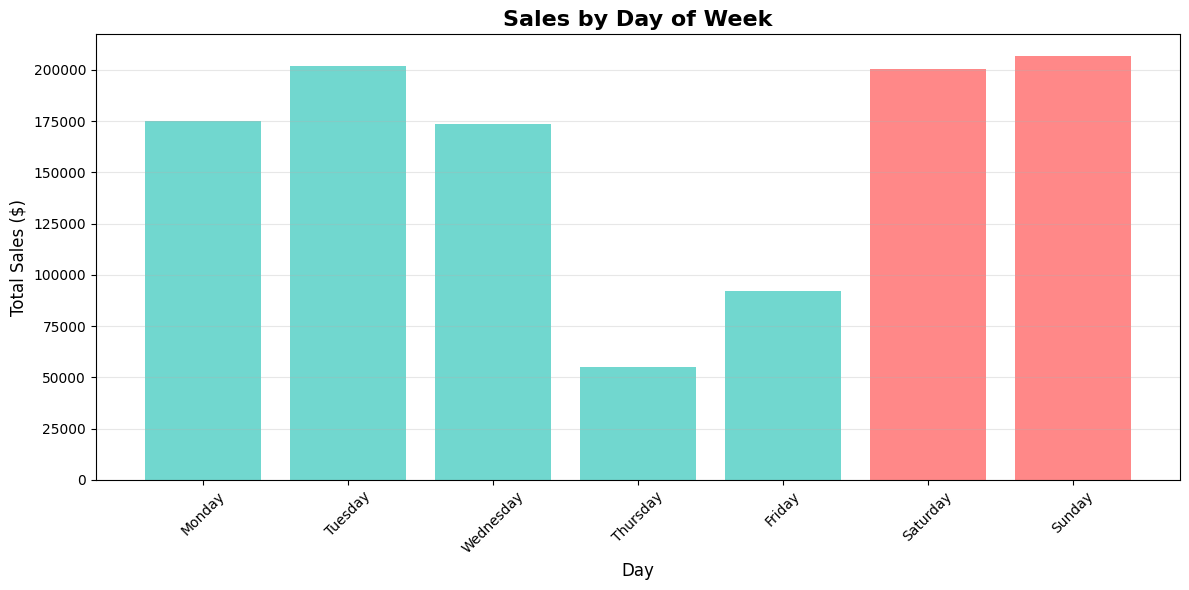


 Sales per Hari:
Day_of_Week
Sunday       207049.3901
Tuesday      202083.6472
Saturday     200268.7667
Monday       174983.3201
Wednesday    173575.8118
Friday        92035.9728
Thursday      55053.9440
Name: sum, dtype: float64

Hari terbaik: Sunday
Hari terburuk: Thursday


In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('Day_of_Week')['Sales'].agg(['sum', 'mean', 'count']).reindex(day_order)

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B' if day in ['Saturday', 'Sunday'] else '#4ECDC4' for day in day_order]
bars = plt.bar(range(7), dow_sales['sum'], color=colors, alpha=0.8)
plt.title('Sales by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(range(7), day_order, rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Sales per Hari:")
print(dow_sales['sum'].sort_values(ascending=False))

best_day = dow_sales['sum'].idxmax()
worst_day = dow_sales['sum'].idxmin()
print(f"\nHari terbaik: {best_day}")
print(f"Hari terburuk: {worst_day}")


TOP PRODUCT CATEGORIES

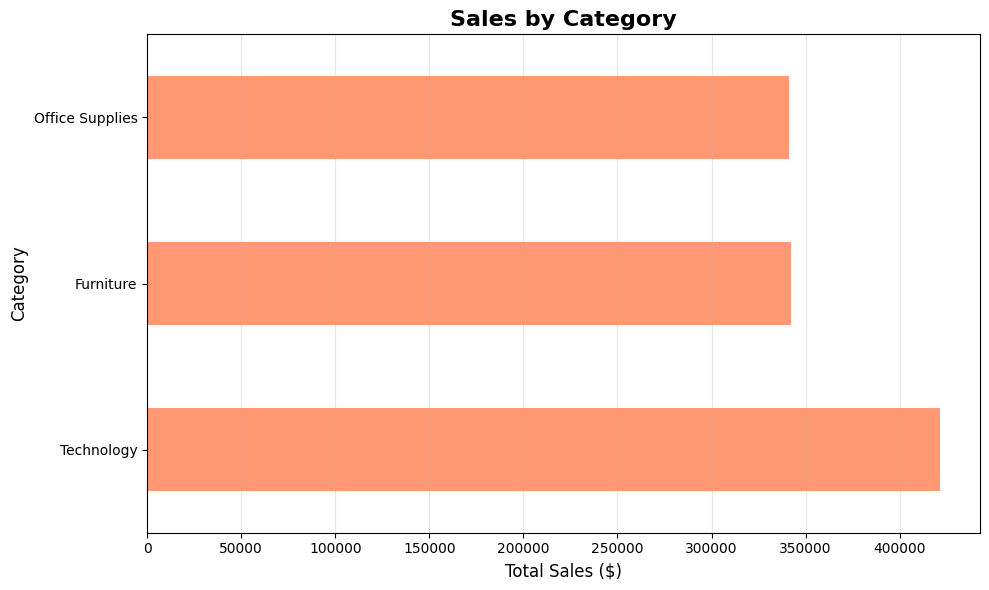


 Top 5 Categories:
                         sum  count
Category                           
Technology       421602.4010    884
Furniture        342208.3097   1007
Office Supplies  341240.1420   2931

 Kontribusi (%):
Category
Technology         38.15
Furniture          30.97
Office Supplies    30.88
Name: percentage, dtype: float64


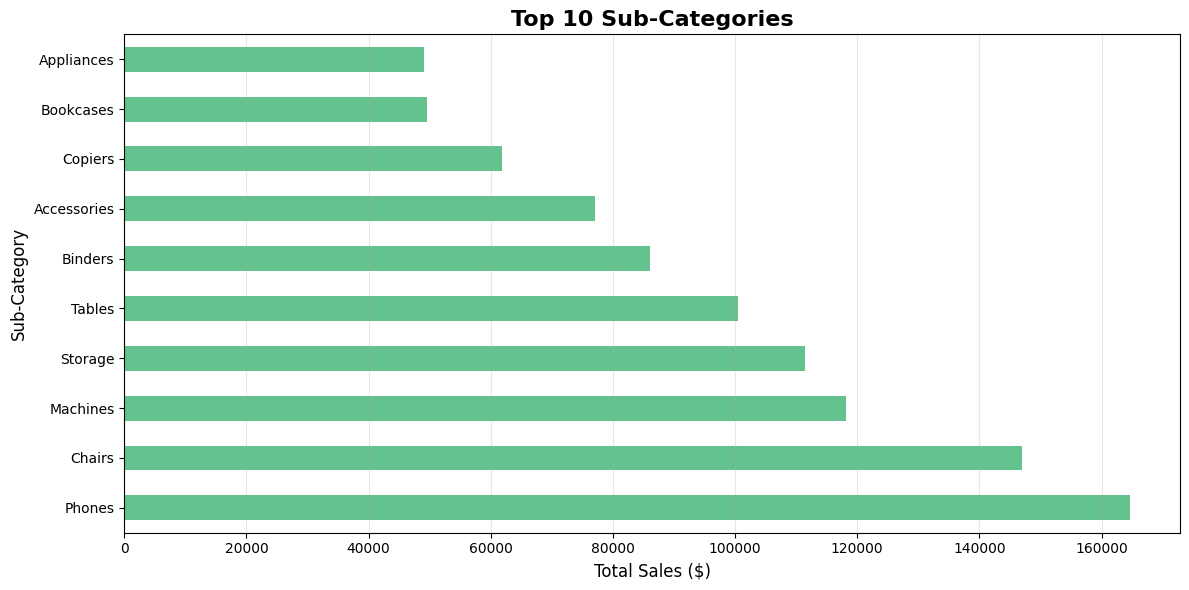


Top 10 Sub-Categories:
Sub-Category
Phones         164609.2580
Chairs         147020.7900
Machines       118103.4710
Storage        111364.5200
Tables         100505.3640
Binders         86014.2390
Accessories     77080.5380
Copiers         61809.1340
Bookcases       49620.0337
Appliances      49069.8650
Name: Sales, dtype: float64


In [10]:
category_sales = df.groupby('Category')['Sales'].agg(['sum', 'count']).sort_values('sum', ascending=False)

plt.figure(figsize=(10, 6))
category_sales['sum'].plot(kind='barh', color='coral', alpha=0.8)
plt.title('Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Top 5 Categories:")
print(category_sales.head())

# Kontribusi persentase
category_sales['percentage'] = (category_sales['sum'] / category_sales['sum'].sum() * 100).round(2)
print("\n Kontribusi (%):")
print(category_sales['percentage'].head())


subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
subcat_sales.plot(kind='barh', color='mediumseagreen', alpha=0.8)
plt.title('Top 10 Sub-Categories', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Sub-Categories:")
print(subcat_sales)

SALES BY REGION

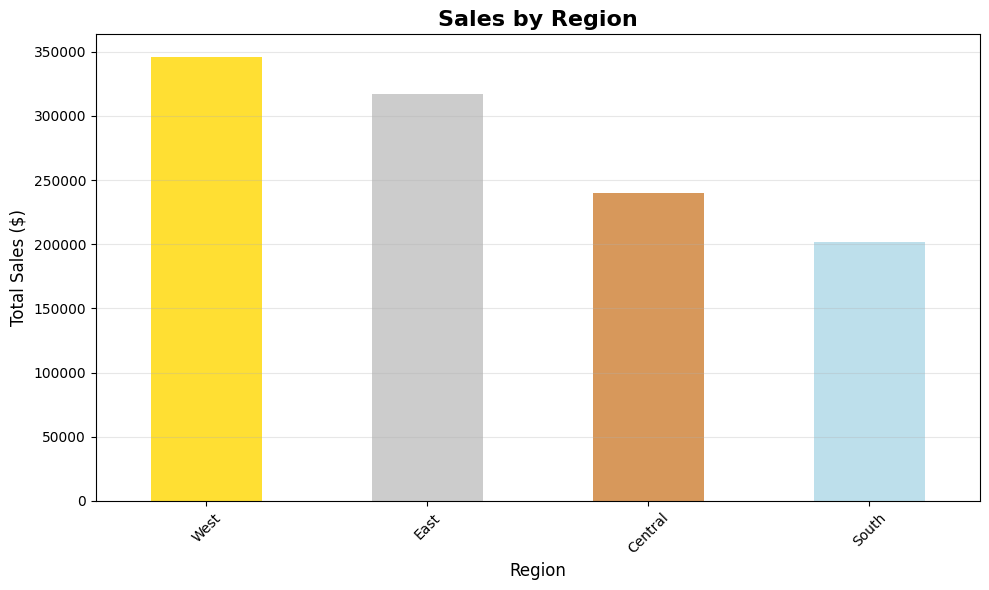


Sales per Region:
                 sum        mean  count
Region                                 
West     346316.7385  225.319934   1537
East     317419.5200  228.523772   1389
Central  239704.6082  211.753187   1132
South    201609.9860  263.887416    764


In [11]:
region_sales = df.groupby('Region')['Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)

plt.figure(figsize=(10, 6))
colors_region = ['gold', 'silver', '#CD7F32', 'lightblue']
region_sales['sum'].plot(kind='bar', color=colors_region, alpha=0.8)
plt.title('Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSales per Region:")
print(region_sales)

SALES BY CUSTOMER SEGMENT

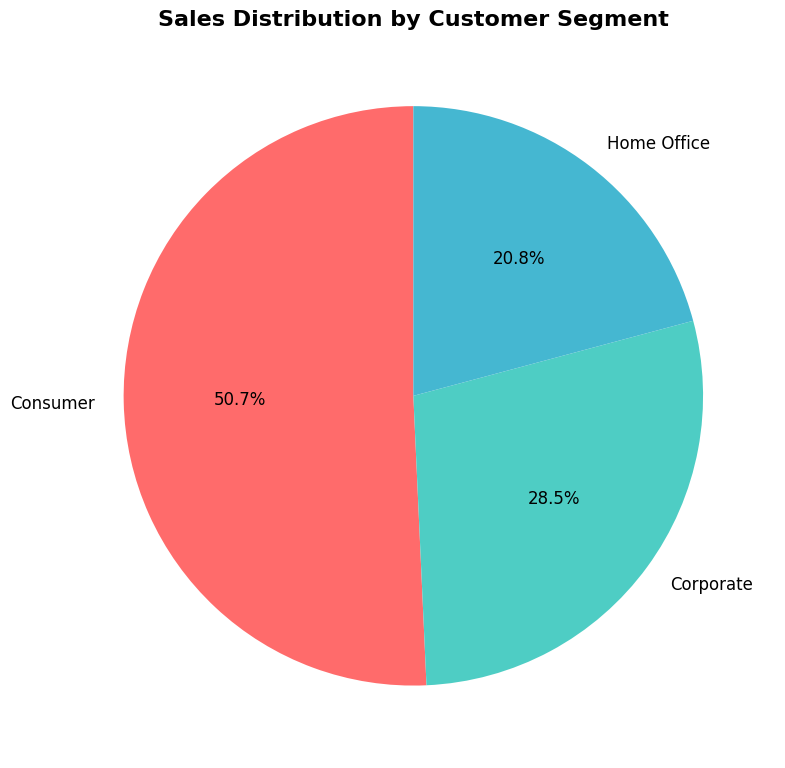


Sales per Segment:
Segment
Consumer       560511.2539
Corporate      314387.0533
Home Office    230152.5455
Name: Sales, dtype: float64


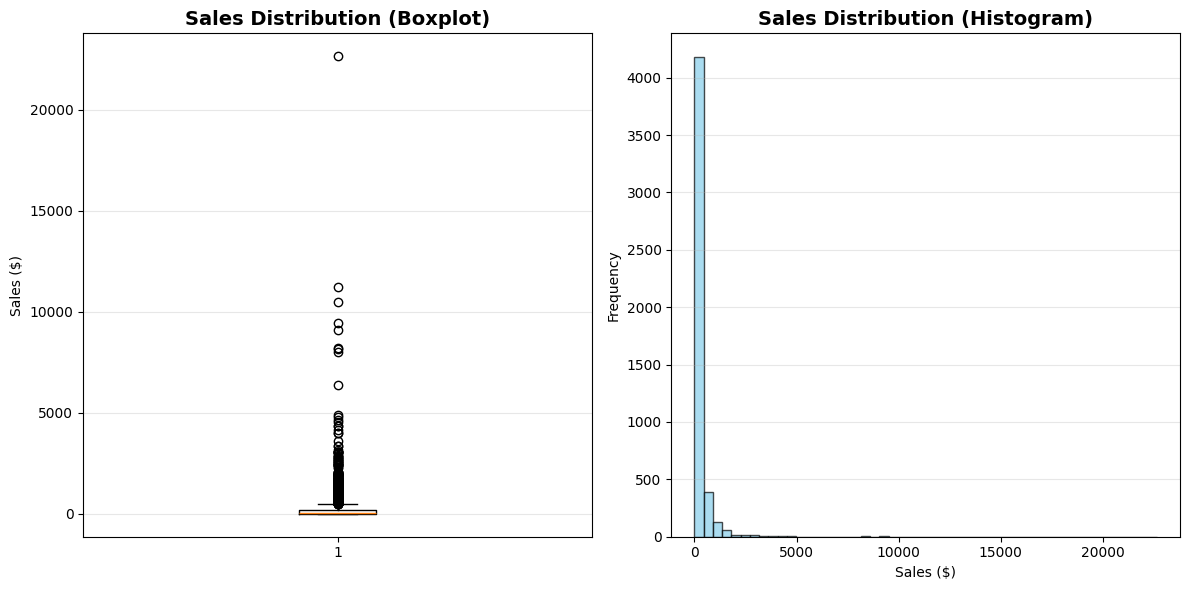


 Jumlah outliers: 579 (12.01%)
 Median Sales: $52.60
 Mean Sales: $229.17


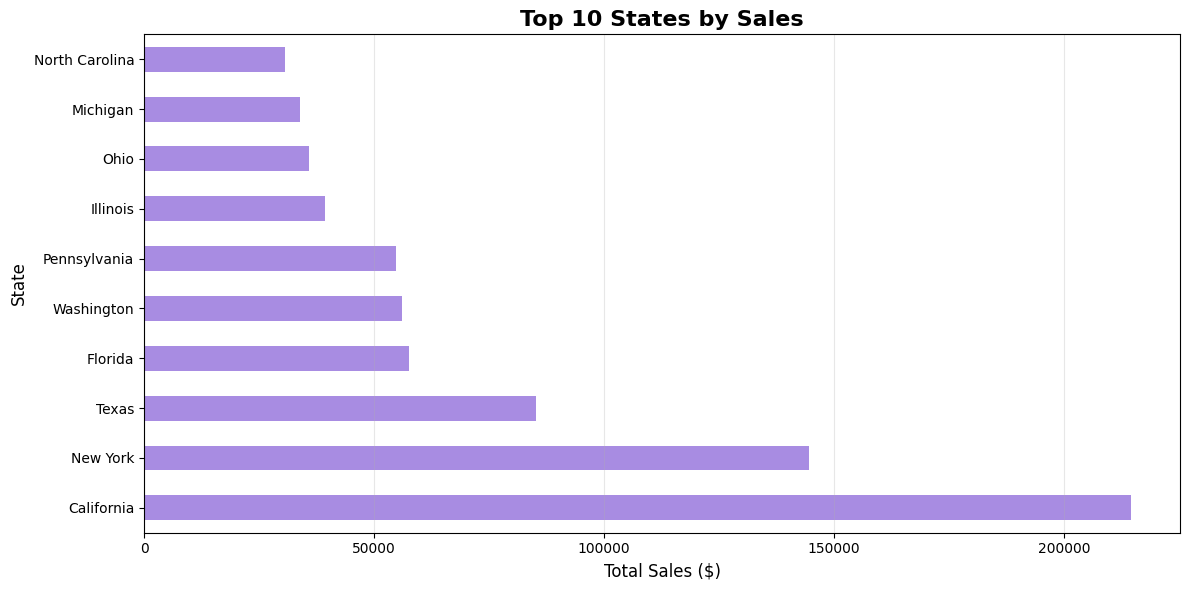


Top 10 States:
State
California        214547.7265
New York          144524.5340
Texas              85205.8792
Florida            57691.3810
Washington         56192.1220
Pennsylvania       54835.9290
Illinois           39395.2030
Ohio               35940.0540
Michigan           33967.3660
North Carolina     30688.8340
Name: Sales, dtype: float64


In [14]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
        startangle=90, colors=colors_pie, textprops={'fontsize': 12})
plt.title('Sales Distribution by Customer Segment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSales per Segment:")
print(segment_sales)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df['Sales'])
plt.title('Sales Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['Sales'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Sales Distribution (Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistik outlier
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]

print(f"\n Jumlah outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f" Median Sales: ${df['Sales'].median():.2f}")
print(f" Mean Sales: ${df['Sales'].mean():.2f}")


state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
state_sales.plot(kind='barh', color='mediumpurple', alpha=0.8)
plt.title('Top 10 States by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 States:")
print(state_sales)